In [1]:
# GOAL :: find optimal L2 weight while varying number of relationships

In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt; plt.style.use("dark_background")
import seaborn as sns
import sys
import sys; sys.path.append("/data/jerrylee/pjt/BIGFAM.v.0.1")
import statsmodels.formula.api as smf
import statsmodels.api as sm
from BIGFAM import obj2, tools, frreg
import importlib

In [2]:
source = "UKB" # UKB, GS

# Step 1. Load data

## Step 1.1 FR-reg

In [3]:
frreg_path = f"/data/jerrylee/pjt/BIGFAM.v.0.1/data/{source}/frreg/REL"
pheno_fns = os.listdir(frreg_path)
len(pheno_fns)

106

## Step 1.2 GCTA results

In [4]:
df_gcta = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM/data/gcta/X.all.gcta",
    sep='\t'
)

In [5]:
df_gc = (df_gcta[df_gcta["sex"] == "all"]
         .reset_index(drop=True))
        #  .drop(columns=["sex", "n_meta", "se_X_GCTA"]))

In [6]:
df_gc["lower_GCTA"] = df_gc["X_GCTA"] - 1.96 * df_gc["se_X_GCTA"]
df_gc["upper_GCTA"] = df_gc["X_GCTA"] + 1.96 * df_gc["se_X_GCTA"]
df_gc = df_gc.drop(columns=["sex", "n_meta", "se_X_GCTA"])
df_gc

,pheno,X_GCTA,lower_GCTA,upper_GCTA
0,Nucleated_red_blood_cell_percentage,0.002071,-0.000066,0.004208
1,"Hair_colour__natural,_before_greying_",0.004818,0.002681,0.006954
2,Urate,0.003119,0.000943,0.005295
3,Standing_height,0.020603,0.017991,0.023214
4,IGF-1,0.007575,0.005215,0.009935
...,...,...,...,...
125,Past_tobacco_smoking,0.003393,0.001164,0.005623
126,Arm_fat-free_mass__right_,0.008903,0.006595,0.011210
127,Forced_vital_capacity__FVC_,0.006721,0.004291,0.009151
128,Neuroticism_score,0.002500,-0.000026,0.005025


# Step 2. various relationship

## Step 2.1 DOR level

In [ ]:
df_vrels = pd.DataFrame(
    columns=["pheno", "weight", "d", "X_BIGFAM", "lower_BIGFAM", "upper_BIGFAM"]
)

for pheno_fn in tqdm(pheno_fns):
    pheno = pheno_fn.split(".")[0]
    
    df_frreg = pd.read_csv(
        f"{frreg_path}/{pheno_fn}",
        sep='\t'
    )
    
    for d in sorted(df_frreg["DOR"].unique()):
        df_d = df_frreg[df_frreg["DOR"] == d].copy()
        
        for alp in range(-3, 10):
            result = obj2.estimateX(df_d, 
                                    alpha_dicts={"type": "eta", "weight":alp})
            
            df_vrels.loc[len(df_vrels)] = [pheno, alp, d,
                                            np.median(result["X"]),
                                            np.percentile(result["X"], 2.5), 
                                            np.percentile(result["X"], 97.5)]

### Step 2.1.1 plot

In [7]:
df_vrels = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/test/varing_weight.DOR.tsv",
    sep='\t',
)

In [8]:
df_plot = (df_vrels
           .groupby(["pheno", "weight", "d"])
           .mean()
           .reset_index())

excludes = ["Sitting_height", 
            "Platelet_count", 
            "SHBG"]

df_plot = (df_plot[~df_plot["pheno"].isin(excludes)]
          .reset_index(drop=True))
df_plot

,pheno,weight,d,X_BIGFAM,lower_BIGFAM,upper_BIGFAM
0,Alanine_aminotransferase,-3,1,-0.040478,-0.116023,0.024458
1,Alanine_aminotransferase,-3,2,0.071431,-0.066856,0.259082
2,Alanine_aminotransferase,-3,3,0.010207,-0.159062,0.130926
3,Alanine_aminotransferase,-2,1,-0.027020,-0.080193,0.027849
4,Alanine_aminotransferase,-2,2,0.060874,-0.033106,0.159660
...,...,...,...,...,...,...
4012,Whole_body_water_mass,8,2,-0.000911,-0.001816,0.000205
4013,Whole_body_water_mass,8,3,0.000970,-0.000259,0.002263
4014,Whole_body_water_mass,9,1,0.000678,-0.000411,0.001688
4015,Whole_body_water_mass,9,2,-0.000585,-0.001234,0.000257


In [9]:
df_mrg = pd.merge(df_plot,
                  df_gc, 
                  on="pheno")

In [10]:
x_thred = 1e-5

In [11]:
df_mrg_filtered = (df_mrg[(df_mrg["lower_BIGFAM"] > x_thred)\
                        & (df_mrg["lower_GCTA"] > x_thred)]
                   .reset_index(drop=True))

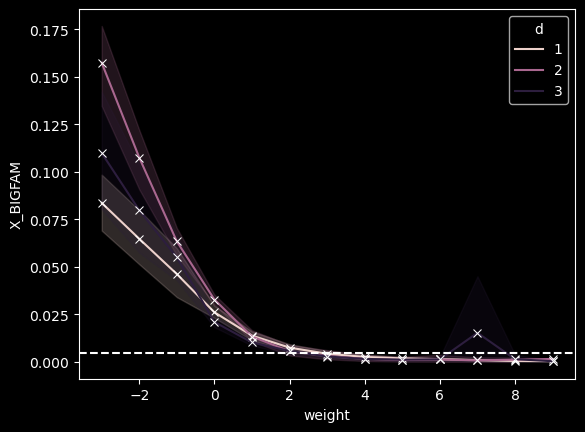

In [12]:
sns.lineplot(
    data=df_mrg_filtered,
    x="weight",
    y="X_BIGFAM",
    hue="d",
    marker="x")

plt.axhline(df_mrg["X_GCTA"].mean(), ls="--")

In [13]:
df_corr = pd.DataFrame(columns=["d", "weight", "corr"])

for d in sorted(df_mrg_filtered["d"].unique()):
    for w in sorted(df_mrg["weight"].unique()):
        tmp_pos = df_mrg_filtered[(df_mrg_filtered["weight"] == w) & (df_mrg_filtered["d"] == d)]
        # tmp = tmp[~tmp["pheno"].isin(excludes)]
        
        # corr = tmp[["X_BIGFAM", "X_GCTA"]].corr().iloc[0, 1]
        corr_pos = tmp_pos[["X_BIGFAM", "X_GCTA"]].corr().iloc[0, 1]
        
        # df_corr.loc[len(df_corr)] = [w, "all", corr]
        df_corr.loc[len(df_corr)] = [d, w, corr_pos]

<Axes: xlabel='weight', ylabel='corr'>

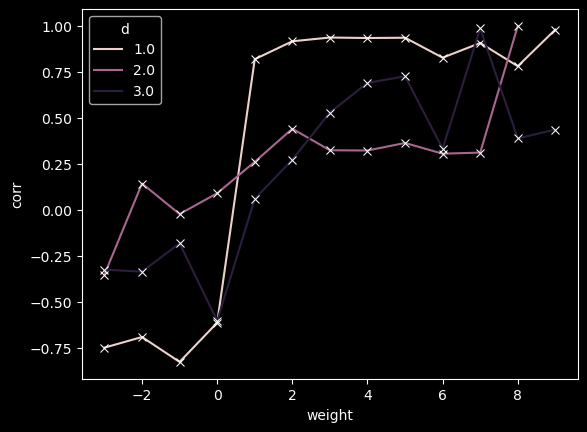

In [14]:
sns.lineplot(
    data=df_corr,
    x="weight",
    y="corr",
    hue="d",
    marker="x"
)

In [16]:
for_plot = df_mrg_filtered[df_mrg_filtered["weight"] == 2]
for_plot.groupby("d").mean()[["X_BIGFAM", "X_GCTA"]]
# for_plot[["X_BIGFAM", "X_GCTA"]].mean()

,X_BIGFAM,X_GCTA
d,,
1,0.007542,0.005208
2,0.005618,0.004527
3,0.005783,0.005014


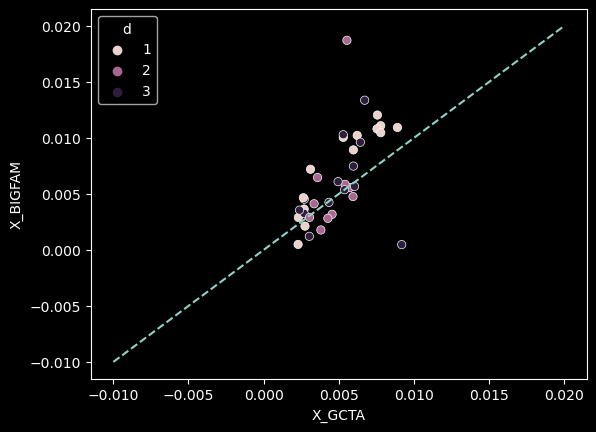

In [17]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=for_plot,
    x="X_GCTA",
    y="X_BIGFAM",
    hue="d",
    ax=ax)
ax.plot([-0.01, 0.02], [-0.01, 0.02], ls="--")

# for i, pheno in enumerate(for_plot["pheno"]):
#     x = for_plot.loc[for_plot["pheno"] == pheno, "X_GCTA"].values[0]
#     y = for_plot.loc[for_plot["pheno"] == pheno, "X_BIGFAM"].values[0]
#     ax.annotate(pheno, (x, y), fontsize=8, alpha=0.2)

## Step 2.2 various n_relationship

In [ ]:
df_vrels = pd.DataFrame(
    columns=["pheno", "weight", "n_rel", 
             "X_BIGFAM", "lower_BIGFAM", "upper_BIGFAM"]
)

for ii, pheno_fn in enumerate(tqdm(pheno_fns), len(pheno)):
    pheno = pheno_fn.split(".")[0]
    
    df_frreg = pd.read_csv(
        f"{frreg_path}/{pheno_fn}",
        sep='\t'
    )
    
    for n_rel in range(6, 20, 5):
        n_it = 0
        while n_it < 10:
            df = df_frreg.sample(n_rel).copy()
            
            if sum(df.groupby("DOR").size() >= 2) < 3:
                continue
            
            n_it += 1
            for alp in range(0, 5):
                result = obj2.estimateX(df, 
                                        alpha_dicts={"type": "eta", "weight":alp})
                
                df_vrels.loc[len(df_vrels)] = [pheno, alp, n_rel,
                                                np.median(result["X"]),
                                                np.percentile(result["X"], 2.5), 
                                                np.percentile(result["X"], 97.5)]
    if ii == 5:
        break

In [19]:
# df_vrels.to_csv(
#     "/data/jerrylee/pjt/BIGFAM.v.0.1/test/varing_weight.n_rel.tsv",
#     sep='\t',
#     index=False
# )

df_vrels = pd.read_csv(
    "/data/jerrylee/pjt/BIGFAM.v.0.1/test/varing_weight.n_rel.tsv",
    sep='\t',
)

### step 2.2.1 plot

In [20]:
df_plot = (df_vrels
           .groupby(["pheno", "weight", "n_rel"])
           .mean()
           .reset_index())

excludes = ["Sitting_height", 
            "Platelet_count", 
            "SHBG"]

df_plot = (df_plot[~df_plot["pheno"].isin(excludes)]
          .reset_index(drop=True))
df_plot

,pheno,weight,n_rel,X_BIGFAM,lower_BIGFAM,upper_BIGFAM
0,Alanine_aminotransferase,-3,6,-0.051350,-0.201771,0.107946
1,Alanine_aminotransferase,-3,9,0.035398,-0.072969,0.145634
2,Alanine_aminotransferase,-3,12,0.004540,-0.087157,0.101709
3,Alanine_aminotransferase,-3,15,0.010249,-0.068546,0.094466
4,Alanine_aminotransferase,-3,18,-0.009479,-0.078505,0.066168
...,...,...,...,...,...,...
6690,Whole_body_water_mass,9,6,0.000064,-0.000478,0.000633
6691,Whole_body_water_mass,9,9,0.000301,-0.000387,0.000914
6692,Whole_body_water_mass,9,12,-0.000035,-0.000928,0.000873
6693,Whole_body_water_mass,9,15,0.000585,-0.000882,0.001986


<Axes: xlabel='weight', ylabel='X_BIGFAM'>

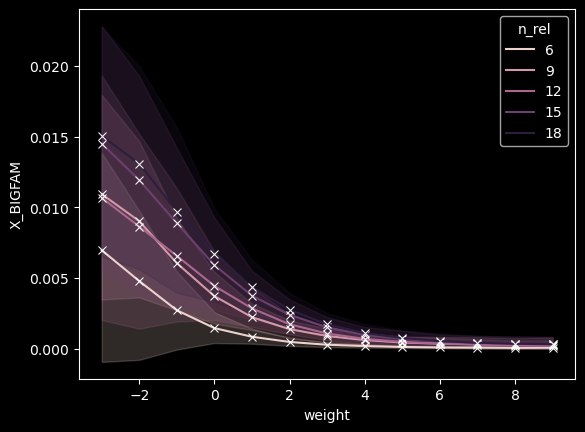

In [21]:
sns.lineplot(
    data=df_plot,
    x="weight",
    y="X_BIGFAM",
    hue="n_rel",
    marker="x")

In [22]:
df_mrg = pd.merge(df_plot,
                  df_gc, 
                  on="pheno")

In [23]:
x_thred = 1e-5

In [24]:
df_mrg_filtered = (df_mrg[(df_mrg["lower_BIGFAM"] > x_thred)\
                        & (df_mrg["lower_GCTA"] > x_thred)]
                   .reset_index(drop=True))

In [26]:
df_corr = pd.DataFrame(columns=["n_rel", "weight", "corr"])

for n_rel in sorted(df_mrg_filtered["n_rel"].unique()):
    for w in sorted(df_mrg["weight"].unique()):
        tmp_pos = df_mrg_filtered[(df_mrg_filtered["weight"] == w) & (df_mrg_filtered["n_rel"] == n_rel)]
        # tmp = tmp[~tmp["pheno"].isin(excludes)]
        
        # corr = tmp[["X_BIGFAM", "X_GCTA"]].corr().iloc[0, 1]
        corr_pos = tmp_pos[["X_BIGFAM", "X_GCTA"]].corr().iloc[0, 1]
        
        # df_corr.loc[len(df_corr)] = [w, "all", corr]
        df_corr.loc[len(df_corr)] = [n_rel, w, corr_pos]

<Axes: xlabel='weight', ylabel='corr'>

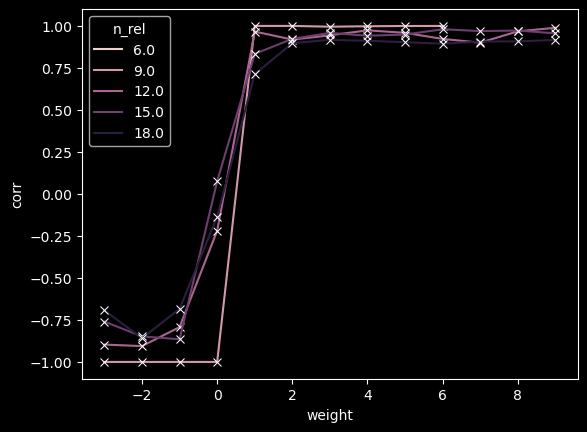

In [29]:
sns.lineplot(
    data=df_corr,
    x="weight",
    y="corr",
    hue="n_rel",
    marker="x"
)

In [36]:
for_plot = df_mrg_filtered[df_mrg_filtered["weight"] == 3]

for_plot.groupby("n_rel")[["X_BIGFAM", "X_GCTA"]].mean()

,X_BIGFAM,X_GCTA
n_rel,,
9,0.002008,0.003414
12,0.003834,0.004840
15,0.004237,0.004450
18,0.005623,0.004689


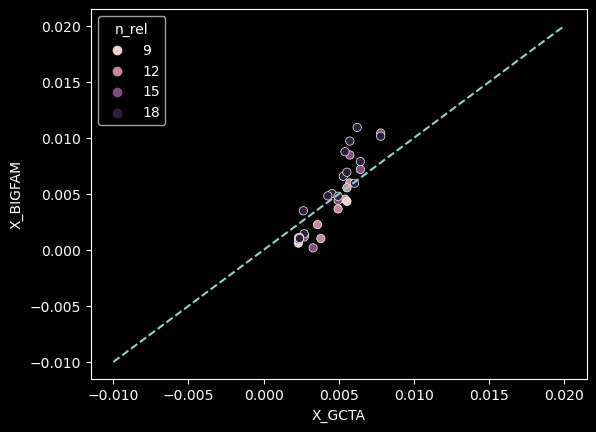

In [37]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=for_plot,
    x="X_GCTA",
    y="X_BIGFAM",
    hue="n_rel",
    ax=ax)
ax.plot([-0.01, 0.02], [-0.01, 0.02], ls="--")

# for i, pheno in enumerate(for_plot["pheno"]):
#     x = for_plot.loc[for_plot["pheno"] == pheno, "X_GCTA"].values[0]
#     y = for_plot.loc[for_plot["pheno"] == pheno, "X_BIGFAM"].values[0]
#     ax.annotate(pheno, (x, y), fontsize=8, alpha=0.2)